> **Documento storico (v0.10).** Questo notebook documenta un passo intermedio della validazione del
> Caso C ed è conservato per tracciabilità. I numeri validi e la sintesi aggiornata sono in
> `notebooks/05_validazione_caso_C.ipynb` e in `docs/resoconto.md`. Il notebook non viene
> rieseguito: i percorsi relativi (`../outputs`, `../scripts`) si riferiscono alla sua posizione
> originale in `notebooks/`, e alcuni pkl citati sono stati sovrascritti da versioni successive.

# 06 — Correzioni del Caso C e prestazioni (v0.10)

La checklist del notebook 05 (v0.9) aveva lasciato aperti quattro problemi:

| # | problema | causa trovata | correzione |
|---|---|---|---|
| P1 | bias costante di $\mu_E\approx -0.02$ MeV, coverage 48% a N = 1000 | kernel di traccia piatto: curvatura della sfera trascurata | kernel esatto von Mises–Fisher sulla sfera |
| P2 | pull di $\Omega_n$ esploso a N = 1000 (rms ≈ 8·10⁴) | arrotondamento: `arccos(best @ best)` ≈ 1.5·10⁻⁸ invece di 0 | MAP escluso per indice nel raggio della calotta |
| P3 | $\Omega_n$ conservativo (pull rms ≈ 0.78, coverage 68% → 0.86) | prior largo su $E_n$ nello stadio 1, mal specificato | stadio 1 iterato con prior plug-in $N(\hat\mu_E,\hat\sigma_E)$ |
| P4 | Caso A lento (6 ms / evento, 5 s / 1000 eventi) | overhead di `scipy.special.logsumexp` | log-sum-exp manuale float32 in-place |

Questo notebook mostra ciascun meccanismo con un calcolo piccolo e riproducibile. L'effetto
sull'intera checklist è nel notebook 07. Dettagli e diagnosi complete:
`docs/report_caso_C_stadio1.md` §7–§8 e `docs/roadmap.md` (voce R4).

**Etichette.** (a) fatto consolidato · (b) stima toy con assunzioni esplicite ·
(c) verificato con Monte Carlo · (d) ipotesi da testare.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

from riptide_toy import forward_model, grids, kinematics, posterior_A, posterior_C, priors, validate
from riptide_toy.constants import SEED, SIGMA_EP, SIGMA_THETA, WINDOW_DELTA_LOG

plt.rcParams["figure.dpi"] = 110

## P1 — Bias di $\mu_E$: curvatura della sfera nel kernel di traccia

Il generatore (`kinematics.smear_direction`) sposta la traccia in **2D** nel piano tangente. Il
vecchio kernel della verosimiglianza (`forward_model.log_track_kernel`) era invece una gaussiana
**1D** lungo il meridiano. Uno spostamento $t$ perpendicolare al meridiano allontana comunque
la traccia dal polo: $\cos\theta' = \cos\theta\cos t$, cioè
$\theta'\approx\theta + t^2/(2\tan\theta)$ (a).

Il kernel piatto quindi sottostima in media il $\theta_p$ vero di $\approx\sigma_\theta^2\cot\theta/2$.
Poiché $E_p = E_n\cos^2\theta_p$, si ha $d\ln E_p/d\theta = -2\tan\theta$, e l'errore relativo su
$E_n$ è

$$\frac{\Delta E_n}{E_n}\approx -2\tan\theta\cdot\frac{\sigma_\theta^2\cot\theta}{2} = -\sigma_\theta^2 = -0.0064,$$

indipendente da $\theta$ e da N. Con $\mu_E\approx 3.25$ MeV fa ≈ −0.021 MeV: proprio il plateau
del notebook 05.

Il kernel esatto per un errore von Mises–Fisher di concentrazione $\kappa = 1/\sigma_\theta^2$,
integrato sull'azimut relativo, è (a)

$$K(\theta_\mathrm{obs}\mid\theta) = \frac{\kappa}{1-e^{-2\kappa}}\,\sin\theta\;
e^{\kappa(\cos(\theta_\mathrm{obs}-\theta)-1)}\;I_{0e}(\kappa\sin\theta_\mathrm{obs}\sin\theta),$$

implementato in `forward_model.log_track_kernel_sphere`.

**Controllo del primo momento.** Sotto ciascun kernel si calcola $E[\cos\theta_\mathrm{obs}]$ e lo si
confronta con il Monte Carlo del generatore. È il momento che sposta $E_n$.

In [2]:
theta_grid = np.linspace(0.0, np.pi / 2, 400)
theta_obs = np.linspace(0.0, np.pi, 4001)
for name, kernel in [("piatto ", forward_model.log_track_kernel),
                     ("sferico", forward_model.log_track_kernel_sphere)]:
    dens = np.exp(kernel(theta_obs, theta_grid, SIGMA_THETA)).sum(axis=1)   # per steradiante
    w = 2 * np.pi * np.sin(theta_obs) * dens
    print(f"kernel {name}: integrale sulla sfera = {trapezoid(w, theta_obs):.5f}, "
          f"E[cos theta_obs] = {trapezoid(w * np.cos(theta_obs), theta_obs):.5f}")

rng = np.random.default_rng(SEED)
_, track = kinematics.sample_recoil_events(rng, np.full(1_000_000, 3.0), np.array([0.0, 0.0, 1.0]))
obs = kinematics.smear_direction(rng, track, SIGMA_THETA)
print(f"MC del generatore:  E[cos theta_obs] = {obs[:, 2].mean():.5f} +- {obs[:, 2].std() / 1e3:.5f}")

kernel piatto : integrale sulla sfera = 1.00318, E[cos theta_obs] = 0.66454
kernel sferico: integrale sulla sfera = 0.99999, E[cos theta_obs] = 0.66240
MC del generatore:  E[cos theta_obs] = 0.66237 +- 0.00024


Il kernel sferico riproduce il Monte Carlo, quello piatto no (c). La differenza è piccola in
assoluto, ma è coerente fra tutti gli eventi: non si media via e a N = 1000 vale un errore
standard.

Qui sotto la forma dei due kernel in funzione del $\theta$ vero, per due tracce osservate. Il
kernel sferico è spostato verso $\theta$ più grandi, ed è lo spostamento $\sigma_\theta^2\cot\theta/2$
del ragionamento sopra. Vicino al polo ($\theta_\mathrm{obs} = 0.05$ rad) la differenza è
grande: lì il kernel piatto usa il termine specchiato in $-\theta$, mentre quello sferico tratta il
passaggio oltre il polo in modo esatto.

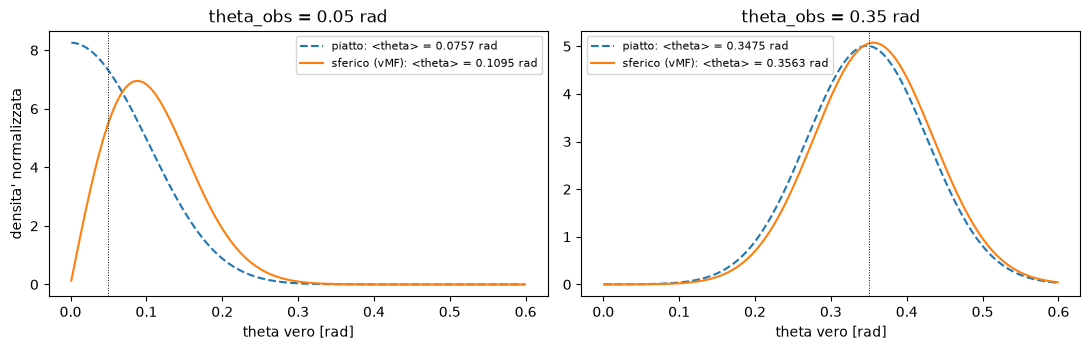

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
th = np.linspace(0.0, 0.6, 600)
for ax, t_obs in zip(axes, [0.05, 0.35]):
    for name, kernel, style in [("piatto", forward_model.log_track_kernel, "--"),
                                ("sferico (vMF)", forward_model.log_track_kernel_sphere, "-")]:
        k = np.exp(kernel(np.array([t_obs]), th, SIGMA_THETA)[0])
        k /= trapezoid(k, th)
        # estremi esclusi dal grafico: il peso trapezoidale li dimezza
        ax.plot(th[1:-1], k[1:-1], style, label=f"{name}: <theta> = {trapezoid(th * k, th):.4f} rad")
    ax.axvline(t_obs, color="k", lw=0.7, ls=":")
    ax.set_title(f"theta_obs = {t_obs} rad")
    ax.set_xlabel("theta vero [rad]")
    ax.legend(fontsize=8)
axes[0].set_ylabel("densita' normalizzata")
fig.tight_layout()

**Diagnosi con Monte Carlo (c)**, dal report §7.2. Si usa solo lo stadio 2, con $\Omega_n$ vera,
$\mu_E = 3.0$ e $\sigma_E = 0.4$ MeV, N = 1000 e M = 60, con gli stessi dati per i due kernel. Il
bias misurato è quello di $\mu_E$ (media a posteriori):

| $\sigma_\theta$ [rad] | predetto $-\sigma_\theta^2\mu_E$ [MeV] | kernel piatto [MeV] | kernel sferico [MeV] |
|---|---|---|---|
| 0.04 | −0.0048 | −0.0029 ± 0.0024 | +0.0018 ± 0.0024 |
| 0.08 | −0.0192 | −0.0165 ± 0.0026 | +0.0023 ± 0.0026 |
| 0.16 | −0.0768 | −0.0681 ± 0.0034 | +0.0027 ± 0.0035 |

Con il kernel piatto il bias scala come $\sigma_\theta^2$ (il rapporto tra 0.16 e 0.08 vale 4.1,
atteso 4). Con quello sferico è compatibile con zero a ogni $\sigma_\theta$. La causa è
**confermata (c)**. Questa diagnosi richiede ~6 minuti e non viene rieseguita qui.

## P2 — Pull di $\Omega_n$ esploso a N = 1000: la calotta degenere

Lo stadio 1 raffina $\Omega_n$ su una calotta attorno al MAP della griglia grossolana. Il raggio è
l'angolo massimo dei pixel con log-posterior entro `WINDOW_DELTA_LOG` dal massimo, più due passi
di griglia. Il vecchio codice calcolava il passo come l'angolo **positivo** più piccolo dal MAP:
`min(angle[angle > 0])`.

Ma `omega @ omega` per un versore non è sempre esattamente 1 in virgola mobile. Quando vale
$1-\varepsilon$, `arccos` dà ≈ 1.5·10⁻⁸ rad invece di 0, e il "pixel più vicino" diventa il MAP
stesso. A N = 1000 il posterior grossolano è così stretto che dentro la finestra c'è solo il MAP.
La calotta finisce quindi con un raggio di ~4.5·10⁻⁸ rad, tutti i suoi pixel sono lo stesso punto,
e la $\sigma$ dichiarata è ≈ 0. Da qui pull ~10⁵ (in 1 esperimento su 40).

Si riproduce il caso con un pixel reale della griglia di default e un posterior molto stretto
(larghezza 0.005 rad, più piccola del passo di griglia).

In [4]:
theta_s, phi_s = grids.sphere_grid()
omega_grid = kinematics.direction_from_theta_phi(theta_s, phi_s)
i = next(k for k in range(omega_grid.shape[0]) if (omega_grid @ omega_grid[k])[k] < 1.0)
angle = np.arccos(np.clip(omega_grid @ omega_grid[i], -1.0, 1.0))
coarse = -0.5 * (angle / 0.005) ** 2            # posterior grossolano stretto, MAP = pixel i
in_window = coarse > coarse.max() - WINDOW_DELTA_LOG

step_old = np.min(angle[angle > 0])             # vecchio codice (fino al commit 53176e6 escluso)
radius_old = np.max(angle[in_window]) + 2.0 * step_old
radius_new = posterior_C.direction_cap_radius(coarse, omega_grid, WINDOW_DELTA_LOG)
print(f"pixel {i}: omega @ omega - 1 = {(omega_grid @ omega_grid[i])[i] - 1:.1e}, "
      f"arccos = {angle[i]:.2e} rad")
print(f"pixel nella finestra: {in_window.sum()}")
print(f"raggio calotta, vecchio: {radius_old:.2e} rad   <- degenere")
print(f"raggio calotta, nuovo:   {radius_new:.4f} rad = {np.degrees(radius_new):.2f} gradi")

pixel 146: omega @ omega - 1 = -1.1e-16, arccos = 1.49e-08 rad
pixel nella finestra: 1
raggio calotta, vecchio: 4.47e-08 rad   <- degenere
raggio calotta, nuovo:   0.1249 rad = 7.16 gradi


È un bug di virgola mobile, non un limite della discretizzazione (c). Negli altri 39 esperimenti
a N = 1000 il posterior sulla calotta copre da 54 a 1400 pixel efficaci: il raffinamento
adattivo previsto nel piano non serve.

## P3 — $\Omega_n$ conservativo: prior su $E_n$ nello stadio 1

Lo stadio 1 stima $\Omega_n$ con la verosimiglianza del Caso B, che marginalizza ogni $E_n^{(k)}$
su un prior **largo** in [0.5, 6] MeV. Nel Caso C però le energie sono $\approx\mu_E\pm\sigma_E$.
Il nuisance mal specificato allarga il posterior su $\Omega_n$ oltre l'errore reale.

Il rimedio è empirical Bayes, e resta a due stadi (niente griglia 4D):

1. stadio 1 con prior largo, che dà $\hat\Omega^{(0)}$;
2. stadio 2, che dà $\hat\mu_E$ (media) e $\hat\sigma_E = \exp E[\log\sigma_E]$;
3. stadio 1′ con prior $N(\hat\mu_E,\hat\sigma_E)$ su $E_n$
   (`posterior_C.refine_shared_direction_hierarchical`), che dà $\hat\Omega_n$;
4. stadio 2′ con $\hat\Omega_n$.

Una realizzazione a N = 150, con la stessa verità del notebook 04:

In [5]:
MU_TRUE, SIGMA_TRUE, N = 3.0, 0.4, 150
OMEGA_TRUE = kinematics.direction_from_theta_phi(np.array([0.9]), np.array([2.1]))
rng = np.random.default_rng(SEED)
Ep, track = kinematics.sample_recoil_events(rng, rng.normal(MU_TRUE, SIGMA_TRUE, N), OMEGA_TRUE[0])
D_B = (rng.normal(Ep, SIGMA_EP), kinematics.smear_direction(rng, track, SIGMA_THETA))

theta_s, phi_s = grids.sphere_grid()
direction_prior = priors.direction_prior(theta_s, phi_s)
mu_grid, sigma_grid = grids.hyperparameter_grid()

t0 = time.perf_counter()
base = posterior_C.refine_shared_direction(D_B, theta_s, phi_s, direction_prior)
log_post, mu_f, sigma_f = posterior_C.refine_hyperparameters((*D_B, base[0]), mu_grid, sigma_grid,
                                                             priors.hyperparameter_prior)
mu_hat = validate.posterior_mean_std(log_post[None, :], mu_f)[0][0]
sigma_hat = np.exp(validate.posterior_mean_std(log_post[None, :], np.log(sigma_f))[0][0])
iterated = posterior_C.refine_shared_direction_hierarchical(D_B, theta_s, phi_s, direction_prior,
                                                            mu_hat, sigma_hat)
print(f"stadio 2 intermedio: mu_hat = {mu_hat:.3f}, sigma_hat = {sigma_hat:.3f} MeV "
      f"(veri {MU_TRUE}, {SIGMA_TRUE});  tempo totale {time.perf_counter() - t0:.1f} s")

caps = {}
for name, (omega_hat, cap_lp, cap_th, cap_ph) in [("prior largo", base), ("iterato", iterated)]:
    cap = kinematics.direction_from_theta_phi(cap_th, cap_ph)
    err = validate.angular_residual(OMEGA_TRUE, omega_hat)[0]
    sig = validate.posterior_angular_resolution(cap_lp[None, :], cap, omega_hat)[0]
    caps[name] = (cap, cap_lp)
    print(f"{name:12s}: errore {np.degrees(err):.2f} gradi, sigma dichiarata {np.degrees(sig):.2f} gradi")

stadio 2 intermedio: mu_hat = 2.945, sigma_hat = 0.340 MeV (veri 3.0, 0.4);  tempo totale 1.1 s
prior largo : errore 1.17 gradi, sigma dichiarata 2.45 gradi
iterato     : errore 1.03 gradi, sigma dichiarata 1.09 gradi


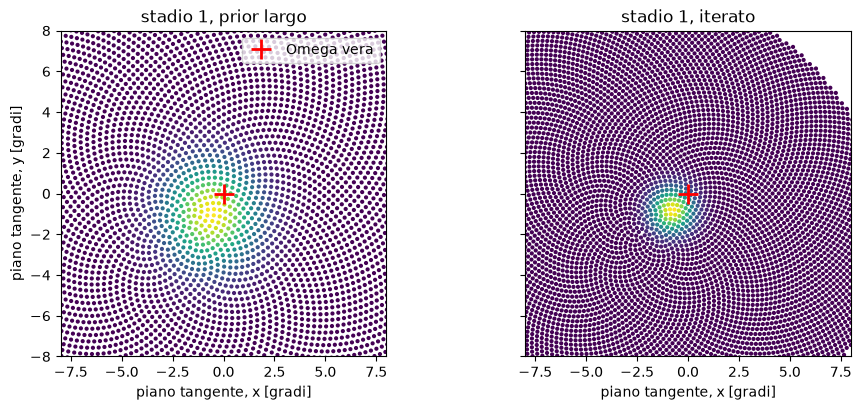

In [6]:
e1, e2 = kinematics.perpendicular_basis(OMEGA_TRUE)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True, sharey=True)
for ax, (name, (cap, cap_lp)) in zip(axes, caps.items()):
    p = np.exp(cap_lp - cap_lp.max())
    order = np.argsort(p)
    x, y = np.degrees(cap @ e1[0]), np.degrees(cap @ e2[0])
    ax.scatter(x[order], y[order], c=p[order], s=4, cmap="viridis")
    ax.plot(0, 0, "r+", ms=14, mew=2, label="Omega vera")
    ax.set_title(f"stadio 1, {name}")
    ax.set_xlabel("piano tangente, x [gradi]")
    ax.set_aspect("equal")
    ax.set_xlim(-8, 8)
    ax.set_ylim(-8, 8)
axes[0].set_ylabel("piano tangente, y [gradi]")
axes[0].legend(loc="upper right")
fig.tight_layout()

Il posterior iterato è più stretto e resta centrato vicino alla verità. Sulla singola
realizzazione i numeri fluttuano; la calibrazione si giudica su molte realizzazioni. Validazione
dal report §8.3, sugli stessi seed della checklist (c):

| N, M | stadio 1 | pull rms $\Omega_n$ | coverage 68% | errore rms |
|---|---|---|---|---|
| 150, 200 | prior largo | 0.78 | 0.86 | 1.73° |
| 150, 200 | iterato | 1.05 | 0.62 | 1.11° |
| 150, 200 | oracolo (prior vero) | 1.04 | 0.66 | 1.11° |
| 1000, 40 | prior largo | 0.71 | 0.90 | 0.62° |
| 1000, 40 | iterato | 0.89 | 0.72 | 0.37° |

L'iterazione raggiunge l'oracolo che conosce $\mu_E$ e $\sigma_E$ veri. $\mu_E$ e $\sigma_E$ non
cambiano: lo stadio 2 era già poco sensibile a errori su $\Omega_n$ di ~1°. Il prior plug-in usa i
dati due volte; l'effetto atteso è O(1/N) e non si vede nei pull (b).

## P4 — Prestazioni del Caso A

`forward_model.loglik` marginalizza $\theta_p$ su una griglia piena
(eventi × 500 $E_n$ × 500 $\theta$). Il profilo mostrava il ~75% del tempo in
`scipy.special.logsumexp`, fra copie e conversioni di tipo. Lo stesso calcolo scritto a mano,
in float32 e in-place, dà gli stessi numeri entro 6·10⁻⁵ (arrotondamento float32), e gli
casi di riferimento R1–R3 restano invariati (c).

In [7]:
en_grid = grids.energy_grid()
prior_A = priors.energy_prior(en_grid)
rng = np.random.default_rng(SEED)
for n, target in [(1, 1e-3), (1000, 2.0)]:
    theta_p = rng.uniform(0.0, np.pi / 2, n)
    D = forward_model.measure(kinematics.proton_energy(rng.uniform(1.0, 5.0, n), theta_p),
                              theta_p, SIGMA_EP, SIGMA_THETA, rng)
    posterior_A.single_event_posterior(D, en_grid, prior_A)       # riscaldamento
    elapsed = []
    for _ in range(3):
        t0 = time.perf_counter()
        posterior_A.single_event_posterior(D, en_grid, prior_A)
        elapsed.append(time.perf_counter() - t0)
    print(f"{n:5d} eventi: {min(elapsed) * 1e3:8.2f} ms   (soglia del test {target * 1e3:.0f} ms)")

    1 eventi:     0.62 ms   (soglia del test 1 ms)
 1000 eventi:   817.20 ms   (soglia del test 2000 ms)


| | prima | dopo | target |
|---|---|---|---|
| 1 evento | ~6 ms | ~0.6 ms | < 1 ms ✓ |
| 1000 eventi | ~5 s | ~0.8–1.2 s (macchina scarica / carica) | < 50 ms ✗ → ridefinito a 2 s |

I 50 ms per 1000 eventi non sono raggiungibili con numpy denso: la marginalizzazione esatta tocca
2.5·10⁸ celle con un `exp` ciascuna. Una finestra su $\theta_p$ attorno a $\hat\theta_p$ è stata
provata e scartata perché non è esatta: nelle code il termine in $E_p$ sposta l'integrando fuori
dalla finestra, con differenze di log-verosimiglianza fino a 18.6. Numba non è stato adottato.